In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

os.listdir("./outputs")


['fe_results_last_1m.xlsx',
 'fe_results_last_3m.xlsx',
 'top_features_last_6m.xlsx',
 'top_features_full.xlsx',
 'model_rank_last_6m.xlsx',
 'top_features_last_3m.xlsx',
 'model_rank_last_1m.xlsx',
 'model_rank_last_3m.xlsx',
 'top_features_last_1m.xlsx',
 'model_rank_full.xlsx',
 'fe_results_last_6m.xlsx',
 'model_rank_last_9m.xlsx',
 'top_features_last_9m.xlsx',
 'fe_results_last_2w.xlsx',
 'fe_results_last_9m.xlsx',
 'fe_results_full.xlsx',
 'model_rank_last_2w.xlsx',
 'top_features_last_2w.xlsx']

In [ ]:
# df = pl.read_excel("./outputs/fe_results_last_1m.xlsx")
# df = pl.read_excel("./outputs/model_rank_last_1m.xlsx")
df = pl.read_excel("./outputs/top_features_last_1m.xlsx").to_pandas().drop(columns="__UNNAMED__0").to_dict(orient="records")
df

[{'feature': 'X853', 'score': 14},
 {'feature': 'X610', 'score': 14},
 {'feature': 'X572', 'score': 14},
 {'feature': 'X586', 'score': 13},
 {'feature': 'X132', 'score': 13},
 {'feature': 'X427', 'score': 13},
 {'feature': 'X344', 'score': 13},
 {'feature': 'X854', 'score': 13},
 {'feature': 'X98', 'score': 13},
 {'feature': 'X691', 'score': 13},
 {'feature': 'X185', 'score': 12},
 {'feature': 'X178', 'score': 12},
 {'feature': 'X179', 'score': 12},
 {'feature': 'X182', 'score': 12},
 {'feature': 'X183', 'score': 12},
 {'feature': 'X184', 'score': 12},
 {'feature': 'X186', 'score': 12},
 {'feature': 'X187', 'score': 12},
 {'feature': 'X188', 'score': 12},
 {'feature': 'X190', 'score': 12},
 {'feature': 'X191', 'score': 12},
 {'feature': 'X882', 'score': 12},
 {'feature': 'X883', 'score': 12},
 {'feature': 'X862', 'score': 12},
 {'feature': 'X690', 'score': 12},
 {'feature': 'X502', 'score': 12},
 {'feature': 'X523', 'score': 12},
 {'feature': 'X126', 'score': 12},
 {'feature': 'X386', 

In [30]:
all_features = pl.DataFrame()

for f in os.listdir("./outputs"):
    if f.startswith("top_features_") and f.endswith(".xlsx"):
        version = f.split(".")[0].split("_")[-1]
        df = pl.read_excel("./outputs/" + f).with_columns(pl.lit(version).alias('version')).drop(["__UNNAMED__0"]).pivot(
            values = "score",
            index = "version",
            on = "feature"
        )
        features = sorted(c for c in df.columns if c != "version")
        df = df.select("version", *features)
        all_features = pl.concat([all_features, df], how="vertical")

all_features

version,X1,X10,X100,X101,X102,X103,X104,X105,X106,X107,X108,X109,X11,X110,X111,X112,X113,X114,X115,X116,X117,X118,X119,X12,X120,X121,X122,X123,X124,X125,X126,X127,X128,X129,X13,X130,…,X874,X875,X876,X877,X878,X879,X88,X880,X881,X882,X883,X884,X885,X886,X887,X888,X889,X89,X890,X9,X90,X91,X92,X93,X94,X95,X96,X97,X98,X99,bidask_delta,bidask_ratio,bidask_size,buysell_delta,buysell_ratio,buysell_size,volume
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""6m""",6,9,8,9,8,7,9,9,8,8,9,8,9,9,9,8,7,9,8,9,9,9,6,9,9,8,9,9,9,9,9,9,9,9,10,9,…,5,9,6,9,6,10,9,9,10,9,10,9,9,9,9,9,9,9,6,9,9,9,8,9,8,9,9,9,6,9,11,10,9,11,9,10,11
"""full""",9,9,8,6,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,6,9,9,9,9,9,6,9,6,9,9,9,…,6,9,9,9,9,10,9,9,9,10,9,6,6,6,6,6,8,10,9,6,9,9,9,9,9,10,9,8,9,9,9,10,12,11,10,10,11
"""3m""",9,9,6,8,10,10,9,9,6,6,9,9,9,9,9,8,6,9,9,9,10,9,6,9,9,9,9,10,9,8,10,9,6,8,11,9,…,5,10,7,9,9,10,10,11,12,11,11,9,9,9,10,10,11,10,11,6,7,9,11,6,10,11,7,9,12,9,11,10,9,11,9,10,9
"""1m""",7,9,10,10,9,7,10,10,10,10,10,7,10,10,10,10,10,10,7,10,11,11,10,10,11,7,10,10,9,10,12,7,10,10,11,7,…,8,10,8,7,7,11,8,10,11,12,12,10,10,10,10,10,12,9,12,10,11,10,11,10,11,9,11,10,13,9,10,9,10,11,10,8,9
"""9m""",8,9,6,6,6,9,9,9,8,9,6,9,9,9,9,6,9,8,9,9,9,6,9,9,9,9,9,9,6,9,9,9,6,9,9,6,…,9,8,8,8,9,10,9,9,9,10,9,9,9,9,9,9,9,10,6,6,9,9,9,9,9,10,9,9,8,9,9,10,12,11,10,8,7
"""2w""",7,9,10,10,7,10,10,10,10,10,9,10,10,10,10,11,11,10,10,10,11,11,10,10,10,10,10,10,10,10,10,7,11,10,11,7,…,8,10,11,7,7,11,8,11,11,12,12,10,10,10,10,10,11,11,11,10,10,9,12,10,11,9,11,10,13,10,10,9,9,11,8,11,12


In [33]:
totals = all_features.select(
    pl.exclude("version").sum()
)
totals

X1,X10,X100,X101,X102,X103,X104,X105,X106,X107,X108,X109,X11,X110,X111,X112,X113,X114,X115,X116,X117,X118,X119,X12,X120,X121,X122,X123,X124,X125,X126,X127,X128,X129,X13,X130,X131,…,X874,X875,X876,X877,X878,X879,X88,X880,X881,X882,X883,X884,X885,X886,X887,X888,X889,X89,X890,X9,X90,X91,X92,X93,X94,X95,X96,X97,X98,X99,bidask_delta,bidask_ratio,bidask_size,buysell_delta,buysell_ratio,buysell_size,volume
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
46,54,48,49,49,52,56,56,51,52,52,52,56,56,56,52,52,55,52,56,59,55,50,56,54,52,56,57,52,55,56,50,48,55,61,47,61,…,41,56,49,49,47,62,53,59,62,64,63,53,53,53,54,54,60,59,55,47,55,55,60,53,58,58,56,55,61,55,60,58,61,66,56,57,59


In [65]:
totals_melted = totals.unpivot(
    on = [],
    variable_name="feature",
    value_name="score"
).sort("score", descending=True)
totals_melted

feature,score
str,i64
"""X610""",68
"""X853""",68
"""X21""",67
"""X239""",67
"""X246""",67
…,…
"""X5""",41
"""X874""",41
"""X446""",40


In [68]:
totals_melted.filter(pl.col("score") >= 65)['feature'].to_list()

['X610',
 'X853',
 'X21',
 'X239',
 'X246',
 'X854',
 'X20',
 'X219',
 'X572',
 'X860',
 'X863',
 'buysell_delta',
 'X300',
 'X301']

<Axes: >

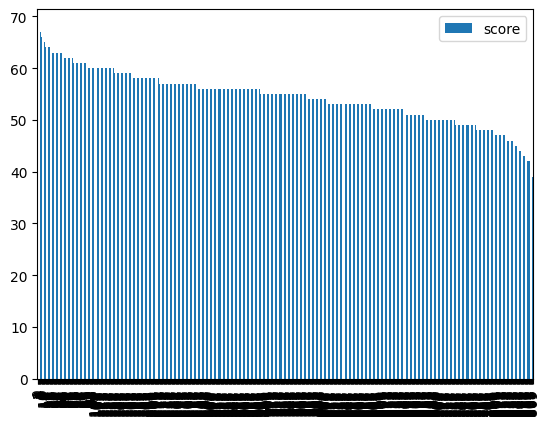

In [56]:
totals_melted.sort("score", descending=True).to_pandas().plot(kind="bar", y="score")

# Features Choices

1. Each Duration and Model has equal score: 
    ```['X610',
    'X853',
    'X21',
    'X239',
    'X246',
    'X854',
    'X20',
    'X219',
    'X572',
    'X860',
    'X863',
    'buysell_delta',
    'X300',
    'X301']```
2. Rank the top features from each backtest, duration, and use that score instead. (ie top feature in a specific duration should have a score of 871). Will face the issue of equal rankings of features.
3. Filter out selective models and then redo the optimization

# Analyzing Model Performance

In [83]:
df = pl.read_excel("./outputs/fe_results_last_1m.xlsx").drop(["total_score"])
df = df.with_columns([
    pl.sum_horizontal(pl.exclude("model")).alias("row_sum")
])
df

model,volume,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,…,X855,X856,X857,X858,X859,X860,X861,X862,X863,X865,X866,X868,X873,X874,X875,X876,X877,X878,X879,X880,X881,X882,X883,X884,X885,X886,X887,X888,X889,X890,bidask_ratio,buysell_ratio,bidask_delta,buysell_delta,buysell_size,bidask_size,row_sum
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""variance_threshold""",1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,87
"""select_kbest_freg""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,…,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30
"""select_kbest_mutualinfo""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,30
"""select_percentile_freg""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,1,1,1,…,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,87
"""select_percentile_mutualinfo""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,87
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""minibatch_dict_learning""",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,869
"""factor_analysis""",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,865
"""nmf""",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,858


In [82]:
pl.concat_list(pl.exclude("model")).arr

In [74]:
df = pl.read_excel("./outputs/model_rank_last_6m.xlsx").sort("features_included", descending=True)
df

model,features_included
str,i64
"""incremental_pca""",1738
"""truncated_svd""",1738
"""factor_analysis""",1738
"""nmf""",1738
"""minibatch_dict_learning""",1734
…,…
"""select_percentile_freg""",174
"""variance_threshold""",172
"""select_kbest_freg""",60


# Data

In [84]:
data = pl.read_parquet("./kaggle/kaggle/input/drw-crypto-market-prediction/train.parquet")
data

bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,…,X856,X857,X858,X859,X860,X861,X862,X863,X864,X865,X866,X867,X868,X869,X870,X871,X872,X873,X874,X875,X876,X877,X878,X879,X880,X881,X882,X883,X884,X885,X886,X887,X888,X889,X890,label,timestamp
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[ns]
15.283,8.425,176.405,44.984,221.389,0.121263,-0.41769,0.005399,0.125948,0.058359,0.027359,0.03578,0.068219,1.034825,-0.029575,0.327805,0.485823,0.668596,0.617389,0.770037,0.857631,1.754456,0.572503,0.883229,0.58567,0.816321,0.529973,0.508244,0.448616,1.341892,1.406392,0.953631,1.183991,1.474789,0.774389,0.660586,0.269043,…,-0.216525,0.200508,0.492433,-0.51249,0.541286,-0.336399,-1.027483,0.21857,0.0,1.728155,0.62414,0.0,-0.051211,0.0,0.0,0.0,0.0,0.691754,0.242124,2.096157,3.369195,0.244667,0.286611,0.722679,0.901931,1.000007,1.925423,1.847943,0.005676,0.190791,0.369691,0.37763,0.210153,0.159183,0.530636,0.562539,2023-03-01 00:00:00
38.59,2.336,525.846,321.95,847.796,0.302841,-0.049576,0.356667,0.481087,0.237954,0.208359,0.217057,0.249624,0.948694,-0.183488,0.150526,0.308421,0.492232,0.529787,0.682958,0.770965,1.686504,0.273357,0.591695,0.442391,0.674792,0.460741,0.439681,0.380399,1.304113,1.003783,0.776628,1.015943,1.312735,0.696895,0.584217,0.231104,…,-0.180112,0.213252,0.479806,-0.180527,0.450331,-0.31915,-1.024055,0.088014,0.0,1.665698,0.622775,0.0,-0.079621,0.0,0.0,0.0,0.0,0.691665,0.242091,2.46103,4.127584,0.321394,0.31246,0.746452,0.912371,1.003153,1.928569,1.849468,0.005227,0.18466,0.363642,0.374515,0.209573,0.158963,0.530269,0.533686,2023-03-01 00:01:00
0.442,60.25,159.227,136.369,295.596,0.167462,-0.291212,0.083138,0.206881,0.101727,0.072778,0.081564,0.114166,0.896459,-0.261779,0.044571,0.200608,0.384558,0.476229,0.629848,0.718232,1.656707,0.140156,0.457268,0.376524,0.610116,0.429751,0.409316,0.350359,1.28325,0.760801,0.670816,0.917205,1.219124,0.653355,0.541739,0.210095,…,-0.265966,0.191734,0.440207,-0.108209,0.420681,-0.316953,-1.024056,-0.147363,0.0,1.666893,0.621414,0.0,-0.080427,0.0,0.0,0.0,0.0,0.691674,0.242093,2.493249,4.182112,0.326701,0.314636,0.746681,0.911129,1.002502,1.928047,1.849282,0.004796,0.178719,0.357689,0.371424,0.208993,0.158744,0.529901,0.546505,2023-03-01 00:02:00
4.865,21.016,335.742,124.963,460.705,0.072944,-0.43659,-0.102483,0.017551,0.007149,-0.021681,-0.012936,0.019634,0.732634,-0.535845,-0.273947,-0.124959,0.056438,0.311539,0.465377,0.554022,1.663491,0.152084,0.468778,0.383696,0.618529,0.435326,0.415523,0.356895,1.319538,0.955549,0.789646,1.044941,1.353001,0.72392,0.613462,0.246212,…,-0.322244,0.183687,0.404295,-0.169373,0.386584,-0.314775,-1.024058,-0.09459,0.0,1.735322,0.620057,0.0,-0.094702,0.0,0.0,0.0,0.0,0.69121,0.24193,2.525526,4.292975,0.350791,0.32357,0.753829,0.913363,1.002985,1.928621,1.849608,0.004398,0.172967,0.351832,0.368358,0.208416,0.158524,0.529534,0.357703,2023-03-01 00:03:00
27.158,3.451,98.411,44.407,142.818,0.17382,-0.213489,0.096067,0.215709,0.107133,0.078976,0.087818,0.120426,0.763537,-0.430945,-0.205298,-0.062118,0.117266,0.341493,0.495591,0.584519,1.668419,0.156177,0.472732,0.3871,0.623192,0.439034,0.419868,0.361572,1.324595,0.90546,0.78375,1.047708,1.36188,0.732001,0.622712,0.251095,…,-0.369625,0.192377,0.415438,-0.198976,0.389969,-0.312628,-1.02406,0.162221,0.0,1.712096,0.618703,0.0,-0.091884,0.0,0.0,0.0,0.0,0.691207,0.241928,2.52443,4.306694,0.335599,0.31907,0.747533,0.908904,1.001286,1.927084,1.84895,0.004008,0.167391,0.346066,0.365314,0.207839,0.158304,0.529167,0.362452,2023-03-01 00:04:00
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

In [88]:
data.drop(['timestamp', 'label'])

bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,…,X854,X855,X856,X857,X858,X859,X860,X861,X862,X863,X864,X865,X866,X867,X868,X869,X870,X871,X872,X873,X874,X875,X876,X877,X878,X879,X880,X881,X882,X883,X884,X885,X886,X887,X888,X889,X890
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
15.283,8.425,176.405,44.984,221.389,0.121263,-0.41769,0.005399,0.125948,0.058359,0.027359,0.03578,0.068219,1.034825,-0.029575,0.327805,0.485823,0.668596,0.617389,0.770037,0.857631,1.754456,0.572503,0.883229,0.58567,0.816321,0.529973,0.508244,0.448616,1.341892,1.406392,0.953631,1.183991,1.474789,0.774389,0.660586,0.269043,…,0.2734375,0.418618,-0.216525,0.200508,0.492433,-0.51249,0.541286,-0.336399,-1.027483,0.21857,0.0,1.728155,0.62414,0.0,-0.051211,0.0,0.0,0.0,0.0,0.691754,0.242124,2.096157,3.369195,0.244667,0.286611,0.722679,0.901931,1.000007,1.925423,1.847943,0.005676,0.190791,0.369691,0.37763,0.210153,0.159183,0.530636
38.59,2.336,525.846,321.95,847.796,0.302841,-0.049576,0.356667,0.481087,0.237954,0.208359,0.217057,0.249624,0.948694,-0.183488,0.150526,0.308421,0.492232,0.529787,0.682958,0.770965,1.686504,0.273357,0.591695,0.442391,0.674792,0.460741,0.439681,0.380399,1.304113,1.003783,0.776628,1.015943,1.312735,0.696895,0.584217,0.231104,…,0.273481,0.424977,-0.180112,0.213252,0.479806,-0.180527,0.450331,-0.31915,-1.024055,0.088014,0.0,1.665698,0.622775,0.0,-0.079621,0.0,0.0,0.0,0.0,0.691665,0.242091,2.46103,4.127584,0.321394,0.31246,0.746452,0.912371,1.003153,1.928569,1.849468,0.005227,0.18466,0.363642,0.374515,0.209573,0.158963,0.530269
0.442,60.25,159.227,136.369,295.596,0.167462,-0.291212,0.083138,0.206881,0.101727,0.072778,0.081564,0.114166,0.896459,-0.261779,0.044571,0.200608,0.384558,0.476229,0.629848,0.718232,1.656707,0.140156,0.457268,0.376524,0.610116,0.429751,0.409316,0.350359,1.28325,0.760801,0.670816,0.917205,1.219124,0.653355,0.541739,0.210095,…,0.273524,0.409942,-0.265966,0.191734,0.440207,-0.108209,0.420681,-0.316953,-1.024056,-0.147363,0.0,1.666893,0.621414,0.0,-0.080427,0.0,0.0,0.0,0.0,0.691674,0.242093,2.493249,4.182112,0.326701,0.314636,0.746681,0.911129,1.002502,1.928047,1.849282,0.004796,0.178719,0.357689,0.371424,0.208993,0.158744,0.529901
4.865,21.016,335.742,124.963,460.705,0.072944,-0.43659,-0.102483,0.017551,0.007149,-0.021681,-0.012936,0.019634,0.732634,-0.535845,-0.273947,-0.124959,0.056438,0.311539,0.465377,0.554022,1.663491,0.152084,0.468778,0.383696,0.618529,0.435326,0.415523,0.356895,1.319538,0.955549,0.789646,1.044941,1.353001,0.72392,0.613462,0.246212,…,0.273568,0.400075,-0.322244,0.183687,0.404295,-0.169373,0.386584,-0.314775,-1.024058,-0.09459,0.0,1.735322,0.620057,0.0,-0.094702,0.0,0.0,0.0,0.0,0.69121,0.24193,2.525526,4.292975,0.350791,0.32357,0.753829,0.913363,1.002985,1.928621,1.849608,0.004398,0.172967,0.351832,0.368358,0.208416,0.158524,0.529534
27.158,3.451,98.411,44.407,142.818,0.17382,-0.213489,0.096067,0.215709,0.107133,0.078976,0.087818,0.120426,0.763537,-0.430945,-0.205298,-0.062118,0.117266,0.341493,0.495591,0.584519,1.668419,0.156177,0.472732,0.3871,0.623192,0.439034,0.419868,0.361572,1.324595,0.90546,0.78375,1.047708,1.36188,0.732001,0.622712,0.251095,…,0.273611,0.391759,-0.369625,0.192377,0.415438,-0.198976,0.389969,-0.312628,-1.02406,0.162221,0.0,1.712096,0.618703,0.0,-0.091884,0.0,0.0,0.0,0.0,0.691207,0.241928,2.52443,4.306694,0.335599,0.31907,0.747533,0.908904,1.001286,1.927084,1.84895,0.004008,0.167391,0.346066,0.365314,0.207839,0.158304,0.529167
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4.163,6.805,39.037,55.351,94.388,0.020155,0.0